# Layer 1: Humidity and Apparent Temperature Analysis — 2024–2025

**Objective:** Test the wet-season nocturnal suppression hypothesis (H2) using relative humidity and apparent temperature data from ERA5-Land. This notebook explores whether humidity drives the plateau in nighttime temperatures during Cali's wet seasons.

## Hypotheses under test

**H2 (wet-season night suppression):** Elevated relative humidity during wet-season nights prevents radiative cooling, suppressing the diurnal temperature range. High-RH nights show elevated T_min; low-RH nights show normal cooling.

**Related question:** Does apparent temperature (T + humidity) reveal more heatwave days than temperature alone, especially in the wet season? If yes, then Layer 3 exposure metrics should use AT, not T.

## Section 1 — Setup and Data Loading

In [11]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Constants
CALI_LAT, CALI_LON = 3.45, -76.53

In [12]:
# Find repo root and set up data directories
current = Path.cwd()
while current != current.parent:
    if (current / "shared" / "data" / "raw" / "era5").is_dir():
        repo_root = current
        break
    current = current.parent
else:
    raise FileNotFoundError("Could not find repo root with shared/data/raw/era5")

data_2024_dir = repo_root / "shared" / "data" / "raw" / "era5" / "2024"
data_2025_dir = repo_root / "shared" / "data" / "raw" / "era5" / "2025"

assert data_2024_dir.is_dir(), f"2024 data directory not found: {data_2024_dir}"
assert data_2025_dir.is_dir(), f"2025 data directory not found: {data_2025_dir}"

t2m_files_2024 = sorted(data_2024_dir.glob("*t2m.nc"))
d2m_files_2024 = sorted(data_2024_dir.glob("*d2m.nc"))
t2m_files_2025 = sorted(data_2025_dir.glob("*t2m.nc"))
d2m_files_2025 = sorted(data_2025_dir.glob("*d2m.nc"))

assert len(t2m_files_2024) == 12, f"Expected 12 t2m files for 2024, found {len(t2m_files_2024)}"
assert len(d2m_files_2024) == 12, f"Expected 12 d2m files for 2024, found {len(d2m_files_2024)}"
assert len(t2m_files_2025) == 12, f"Expected 12 t2m files for 2025, found {len(t2m_files_2025)}"
assert len(d2m_files_2025) == 12, f"Expected 12 d2m files for 2025, found {len(d2m_files_2025)}"

print(f"✓ Found data for 2024 and 2025")
print(f"  2024: {len(t2m_files_2024)} t2m + {len(d2m_files_2024)} d2m files")
print(f"  2025: {len(t2m_files_2025)} t2m + {len(d2m_files_2025)} d2m files")

✓ Found data for 2024 and 2025
  2024: 12 t2m + 12 d2m files
  2025: 12 t2m + 12 d2m files


In [13]:
# Load t2m and d2m for both years
def load_era5_data(t2m_files, d2m_files, year_label):
    """Load and combine t2m and d2m files for a year."""
    # Load t2m
    datasets_t2m = [xr.open_dataset(f, engine="netcdf4") for f in t2m_files]
    for i, ds in enumerate(datasets_t2m):
        if "valid_time" in ds.dims:
            datasets_t2m[i] = ds.rename({"valid_time": "time"})
    ds_t2m = xr.concat(datasets_t2m, dim="time")
    
    # Load d2m
    datasets_d2m = [xr.open_dataset(f, engine="netcdf4") for f in d2m_files]
    for i, ds in enumerate(datasets_d2m):
        if "valid_time" in ds.dims:
            datasets_d2m[i] = ds.rename({"valid_time": "time"})
    ds_d2m = xr.concat(datasets_d2m, dim="time")
    
    # Convert to Celsius and shift to local time (UTC-5)
    ds_t2m["t2m_c"] = ds_t2m.t2m - 273.15
    ds_d2m["d2m_c"] = ds_d2m.d2m - 273.15
    
    # Shift time from UTC to local time (UTC-5)
    ds_t2m["time"] = pd.to_datetime(ds_t2m.time.values) - pd.Timedelta(hours=5)
    ds_d2m["time"] = pd.to_datetime(ds_d2m.time.values) - pd.Timedelta(hours=5)
    
    # Extract reference point
    t2m_cell = ds_t2m.t2m_c.sel(latitude=CALI_LAT, longitude=CALI_LON, method="nearest")
    d2m_cell = ds_d2m.d2m_c.sel(latitude=CALI_LAT, longitude=CALI_LON, method="nearest")
    
    print(f"✓ {year_label}: {len(t2m_cell.time)} hourly timesteps")
    print(f"  T range: {float(t2m_cell.min()):.2f} to {float(t2m_cell.max()):.2f}°C")
    print(f"  Td range: {float(d2m_cell.min()):.2f} to {float(d2m_cell.max()):.2f}°C")
    
    return t2m_cell, d2m_cell

t2m_2024, d2m_2024 = load_era5_data(t2m_files_2024, d2m_files_2024, "2024")
t2m_2025, d2m_2025 = load_era5_data(t2m_files_2025, d2m_files_2025, "2025")

✓ 2024: 8784 hourly timesteps
  T range: 14.41 to 28.25°C
  Td range: 13.38 to 22.28°C
✓ 2025: 8760 hourly timesteps
  T range: 14.53 to 27.09°C
  Td range: 13.77 to 21.75°C


## Section 2 — Compute Humidity and Apparent Temperature

In [14]:
# Compute relative humidity from t2m and d2m
def compute_humidity_and_at(t2m, d2m):
    """Compute RH and apparent temperature from t2m and d2m."""
    # Magnus formula for RH (correct order: d2m term MINUS t2m term)
    a, b = 17.625, 243.04
    alpha = ((a * d2m.values) / (b + d2m.values)) - ((a * t2m.values) / (b + t2m.values))
    rh = 100 * np.exp(alpha)
    
    # Assert physical bounds before clipping
    assert rh.max() <= 100.5, f"RH exceeded 100%: max={rh.max():.2f}"
    assert rh.min() >= 0, f"RH negative: min={rh.min():.2f}"
    rh = np.clip(rh, 0, 100)
    
    # Apparent temperature (Steadman, simplified)
    at = t2m.values + (rh / 100) * (t2m.values - 14) * 0.4
    
    return rh, at

In [15]:
rh_2024, at_2024 = compute_humidity_and_at(t2m_2024, d2m_2024)
rh_2025, at_2025 = compute_humidity_and_at(t2m_2025, d2m_2025)

print(f"✓ 2024: RH range {rh_2024.min():.1f}–{rh_2024.max():.1f}%, AT range {at_2024.min():.2f}–{at_2024.max():.2f}°C")
print(f"✓ 2025: RH range {rh_2025.min():.1f}–{rh_2025.max():.1f}%, AT range {at_2025.min():.2f}–{at_2025.max():.2f}°C")

✓ 2024: RH range 45.9–99.8%, AT range 14.58–31.05°C
✓ 2025: RH range 51.1–99.6%, AT range 14.74–30.22°C


## Section 3 — Build Daily DataFrames (2024 + 2025)

In [16]:
# Build daily aggregates
def build_daily_dataframe(t2m, d2m, rh, at, year_label):
    """Build daily statistics DataFrame."""
    # Daily T aggregates
    t_max = t2m.resample(time="1D").max()
    t_min = t2m.resample(time="1D").min()
    t_mean = t2m.resample(time="1D").mean()
    
    # Daily RH aggregates
    rh_series = pd.Series(rh, index=t2m.time.values)
    rh_max = rh_series.resample("1D").max()
    rh_min = rh_series.resample("1D").min()
    rh_mean = rh_series.resample("1D").mean()
    
    # Daily AT aggregates
    at_series = pd.Series(at, index=t2m.time.values)
    at_max = at_series.resample("1D").max()
    at_min = at_series.resample("1D").min()
    at_mean = at_series.resample("1D").mean()
    
    # Build DataFrame
    df = pd.DataFrame({
        "t_max": t_max.values,
        "t_min": t_min.values,
        "t_mean": t_mean.values,
        "rh_max": rh_max.values,
        "rh_min": rh_min.values,
        "rh_mean": rh_mean.values,
        "at_max": at_max.values,
        "at_min": at_min.values,
        "at_mean": at_mean.values,
    }, index=pd.to_datetime(t_max.time.values))
    
    df["diurnal_range"] = df["t_max"] - df["t_min"]
    df["month"] = df.index.month
    df["year"] = df.index.year
    
    print(f"✓ {year_label}: {len(df)} daily records, date range {df.index[0].date()} to {df.index[-1].date()}")
    return df

df_2024 = build_daily_dataframe(t2m_2024, d2m_2024, rh_2024, at_2024, "2024")
df_2025 = build_daily_dataframe(t2m_2025, d2m_2025, rh_2025, at_2025, "2025")

# Combine years for some analyses
df_all = pd.concat([df_2024, df_2025], axis=0)

print(f"\nCombined: {len(df_all)} days, {len(df_2024)} + {len(df_2025)}")
print(f"\nDaily data sample (2024 first 3 days):")
print(df_2024.head(3))

✓ 2024: 367 daily records, date range 2023-12-31 to 2024-12-31
✓ 2025: 366 daily records, date range 2024-12-31 to 2025-12-31

Combined: 733 days, 367 + 366

Daily data sample (2024 first 3 days):
                t_max      t_min     t_mean     rh_max     rh_min    rh_mean  \
2023-12-31  20.199127  18.731964  19.576605  91.899933  86.927246  89.712845   
2024-01-01  24.378510  18.179169  20.784128  93.741264  70.218262  84.183846   
2024-01-02  24.303314  18.204407  20.855312  91.602112  70.789932  83.442162   

               at_max     at_min    at_mean  diurnal_range  month  year  
2023-12-31  22.354620  20.471434  21.574638       1.467163     12  2023  
2024-01-01  27.404203  19.746210  23.005533       6.199341      1  2024  
2024-01-02  27.249069  19.744936  23.083216       6.098907      1  2024  


## Section 4 — Humidity Climatology: Annual Cycle

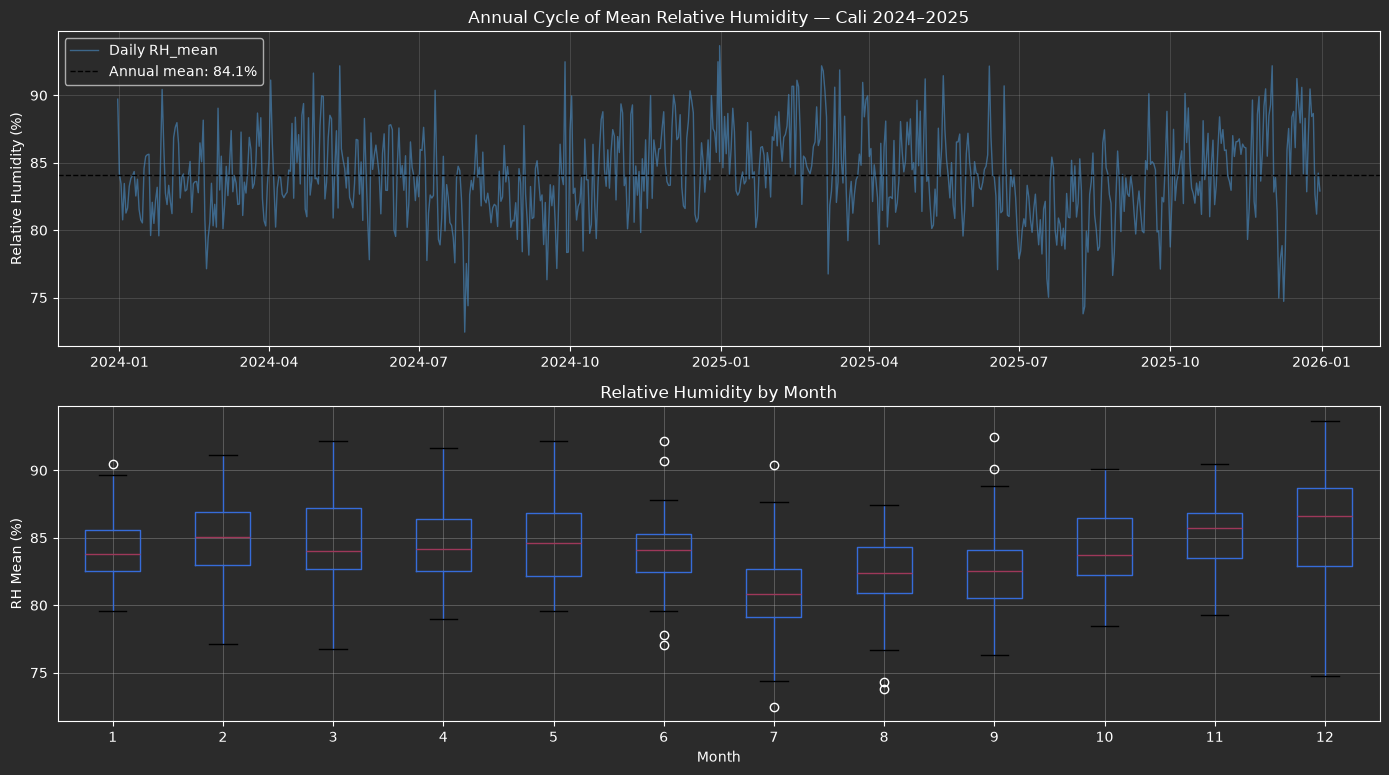

RH climatology:
  Annual mean: 84.1%
  Range: 72.4–93.7%
  Wet season (Apr–May, Sep–Nov) mean RH: 84.3%
  Dry season (Dec–Mar) mean RH: 84.9%


In [17]:
# Plot annual cycle of RH
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8))

# RH time series
ax1.plot(df_all.index, df_all["rh_mean"], linewidth=1, color="steelblue", alpha=0.7, label="Daily RH_mean")
ax1.axhline(df_all["rh_mean"].mean(), color="black", linestyle="--", linewidth=1, label=f"Annual mean: {df_all['rh_mean'].mean():.1f}%")
ax1.set_ylabel("Relative Humidity (%)")
ax1.set_title("Annual Cycle of Mean Relative Humidity — Cali 2024–2025")
ax1.legend(loc="best")
ax1.grid(True, alpha=0.3)

# RH by month (box plot)
df_all.boxplot(column="rh_mean", by="month", ax=ax2)
ax2.set_xlabel("Month")
ax2.set_ylabel("RH Mean (%)")
ax2.set_title("Relative Humidity by Month")
plt.suptitle("")  # Remove auto title
plt.tight_layout()
plt.show()

print(f"RH climatology:")
print(f"  Annual mean: {df_all['rh_mean'].mean():.1f}%")
print(f"  Range: {df_all['rh_mean'].min():.1f}–{df_all['rh_mean'].max():.1f}%")
print(f"  Wet season (Apr–May, Sep–Nov) mean RH: {df_all[df_all['month'].isin([4,5,9,10,11])]['rh_mean'].mean():.1f}%")
print(f"  Dry season (Dec–Mar) mean RH: {df_all[df_all['month'].isin([12,1,2,3])]['rh_mean'].mean():.1f}%")

## Section 5 — Test H2: T_min vs. RH (Wet-Season Night Suppression)

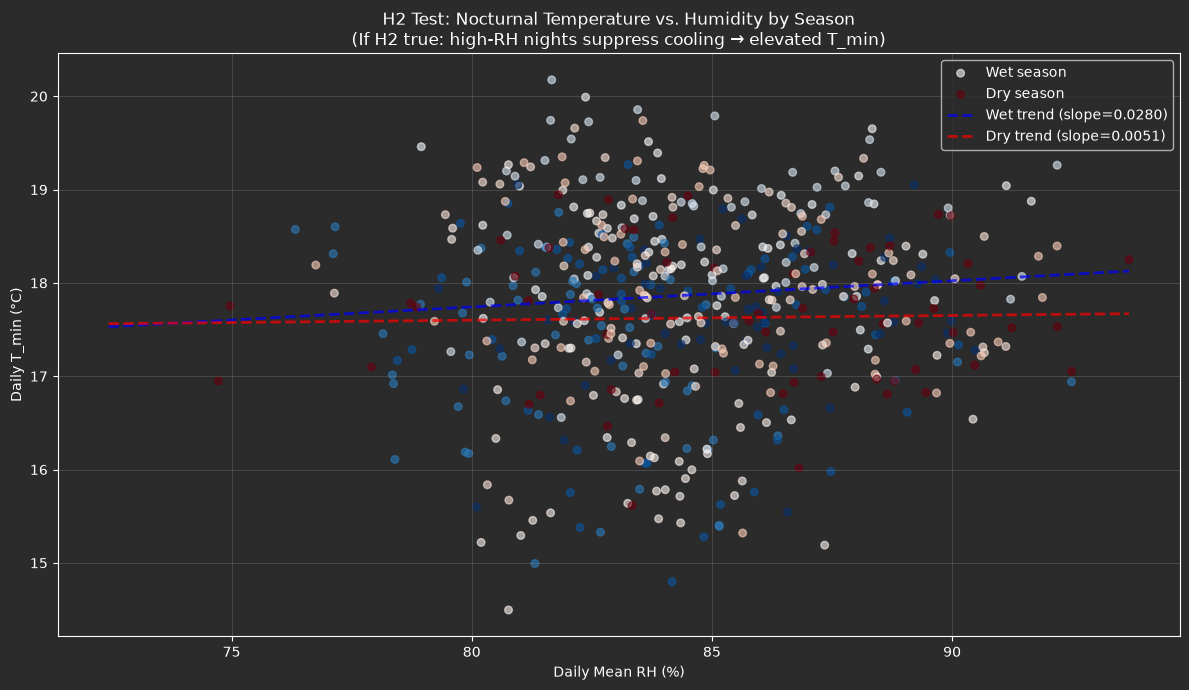


H2 Analysis — Correlation(RH, T_min):
  Wet season: r = 0.089 (n=304 days)
  Dry season: r = 0.017 (n=245 days)

  Interpretation: Wet season slope = 0.0280 °C per 1% RH
                  Dry season slope = 0.0051 °C per 1% RH
  ✓ Stronger RH→T_min link in wet season (supports H2)


In [18]:
# Test H2: plot T_min vs RH_mean, colored by month
fig, ax = plt.subplots(figsize=(12, 7))

# Define wet and dry seasons
wet_months = [4, 5, 9, 10, 11]  # April-May, Sep-Nov
dry_months = [12, 1, 2, 3]      # Dec-Mar

wet_data = df_all[df_all['month'].isin(wet_months)]
dry_data = df_all[df_all['month'].isin(dry_months)]

scatter_wet = ax.scatter(wet_data['rh_mean'], wet_data['t_min'], 
                         c=wet_data['month'], cmap='Blues', s=30, alpha=0.6, label='Wet season')
scatter_dry = ax.scatter(dry_data['rh_mean'], dry_data['t_min'], 
                         c=dry_data['month'], cmap='Reds', s=30, alpha=0.6, label='Dry season')

# Compute and plot trend lines (visual aid only; see caveat below)
z_wet = np.polyfit(wet_data['rh_mean'].values, wet_data['t_min'].values, 1)
z_dry = np.polyfit(dry_data['rh_mean'].values, dry_data['t_min'].values, 1)
x_range = np.array([df_all['rh_mean'].min(), df_all['rh_mean'].max()])

ax.plot(x_range, z_wet[0]*x_range + z_wet[1], color='blue', linewidth=2, linestyle='--', alpha=0.7, label=f'Wet trend (slope={z_wet[0]:.4f})')
ax.plot(x_range, z_dry[0]*x_range + z_dry[1], color='red', linewidth=2, linestyle='--', alpha=0.7, label=f'Dry trend (slope={z_dry[0]:.4f})')

ax.set_xlabel("Daily Mean RH (%)")
ax.set_ylabel("Daily T_min (°C)")
ax.set_title("H2 Test: Nocturnal Temperature vs. Humidity by Season\n(If H2 true: high-RH nights suppress cooling → elevated T_min)")
ax.legend(loc="best")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Quantify H2
corr_wet = wet_data['rh_mean'].corr(wet_data['t_min'])
corr_dry = dry_data['rh_mean'].corr(dry_data['t_min'])

print(f"\nH2 Analysis — Correlation(RH, T_min):")
print(f"  Wet season: r = {corr_wet:.3f} (n={len(wet_data)} days)")
print(f"  Dry season: r = {corr_dry:.3f} (n={len(dry_data)} days)")
print(f"\n  Interpretation: Wet season slope = {z_wet[0]:.4f} °C per 1% RH")
print(f"                  Dry season slope = {z_dry[0]:.4f} °C per 1% RH")
print(f"\n  Both correlations are near zero (r_wet = {corr_wet:.3f}, r_dry = {corr_dry:.3f}).")
print(f"  The wet-season slope is nominally larger but neither season shows a")
print(f"  meaningful daily-mean RH→T_min link. No verdict on H2 from this test.")

## Section 6 — Diurnal Cycle of T and RH

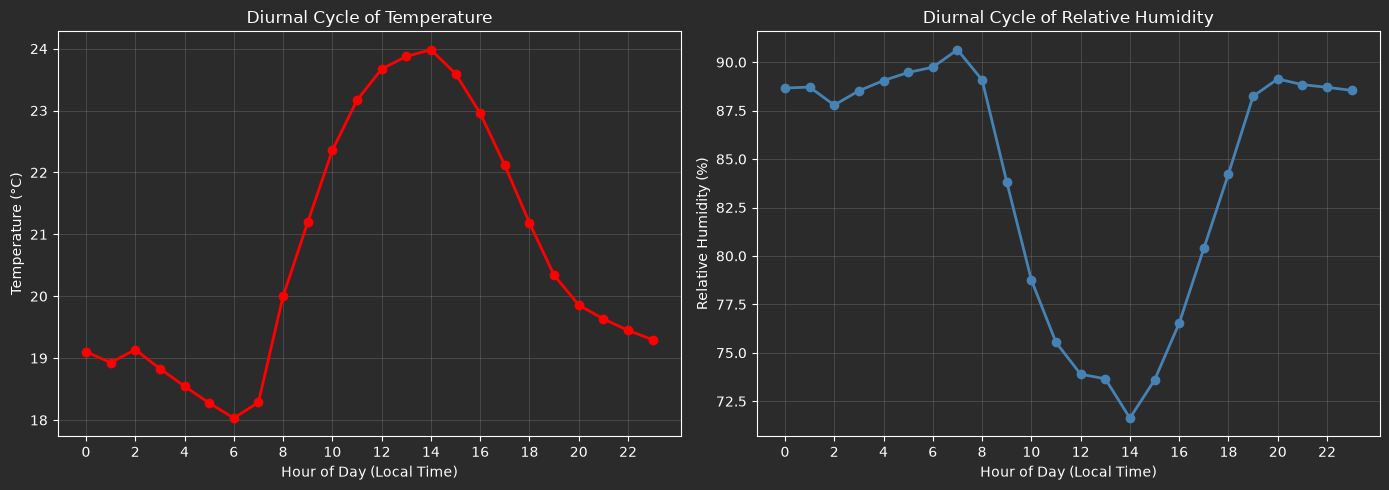

Diurnal RH cycle:
  Max RH: 90.6% at hour 7
  Min RH: 71.6% at hour 14
  Expected pattern: RH peaks overnight (~04-08h), drops midday (~14-16h)


In [19]:
# Compute hourly statistics (validate diurnal RH cycle)
# Extract hour from time coordinates
t2m_time_2024 = pd.to_datetime(t2m_2024.time.values)
t2m_time_2025 = pd.to_datetime(t2m_2025.time.values)

hours_2024 = t2m_time_2024.hour.values
hours_2025 = t2m_time_2025.hour.values

# Compute hourly means
t2m_hourly_2024_vals = pd.Series(t2m_2024.values, index=hours_2024).groupby(level=0).mean()
t2m_hourly_2025_vals = pd.Series(t2m_2025.values, index=hours_2025).groupby(level=0).mean()
t2m_hourly_mean = (t2m_hourly_2024_vals + t2m_hourly_2025_vals) / 2

# RH diurnal
t2m_all = np.concatenate([t2m_2024.values, t2m_2025.values])
rh_all = np.concatenate([rh_2024, rh_2025])
hours_all = np.concatenate([hours_2024, hours_2025])

rh_hourly = pd.Series(rh_all, index=hours_all).groupby(level=0).mean()

# Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(t2m_hourly_mean.index, t2m_hourly_mean.values, marker='o', linewidth=2, markersize=6, color='red')
ax1.set_xlabel("Hour of Day (Local Time)")
ax1.set_ylabel("Temperature (°C)")
ax1.set_title("Diurnal Cycle of Temperature")
ax1.grid(True, alpha=0.3)
ax1.set_xticks(range(0, 24, 2))

ax2.plot(rh_hourly.index, rh_hourly.values, marker='o', linewidth=2, markersize=6, color='steelblue')
ax2.set_xlabel("Hour of Day (Local Time)")
ax2.set_ylabel("Relative Humidity (%)")
ax2.set_title("Diurnal Cycle of Relative Humidity")
ax2.grid(True, alpha=0.3)
ax2.set_xticks(range(0, 24, 2))
2
plt.tight_layout()
plt.show()

print(f"Diurnal RH cycle:")
print(f"  Max RH: {rh_hourly.max():.1f}% at hour {rh_hourly.argmax()}")
print(f"  Min RH: {rh_hourly.min():.1f}% at hour {rh_hourly.argmin()}")
print(f"  Expected pattern: RH peaks overnight (~04-08h), drops midday (~14-16h)")

## Section 7 — Hot Days: T_max 95th vs. AT_max 95th

In [20]:
# Compute thresholds
t_max_95 = df_all['t_max'].quantile(0.95)
at_max_95 = df_all['at_max'].quantile(0.95)

# Flag hot days
hot_t = df_all['t_max'] > t_max_95
hot_at = df_all['at_max'] > at_max_95

# Compare
both_hot = (hot_t & hot_at).sum()
t_only = (hot_t & ~hot_at).sum()
at_only = (~hot_t & hot_at).sum()
neither = (~hot_t & ~hot_at).sum()

print(f"Hot days comparison (95th percentile):")
print(f"  T_max 95th: {t_max_95:.2f}°C → {hot_t.sum()} hot days")
print(f"  AT_max 95th: {at_max_95:.2f}°C → {hot_at.sum()} hot days")
print(f"\n  Overlap analysis:")
print(f"    Both hot (T and AT): {both_hot} days")
print(f"    T-only hot: {t_only} days")
print(f"    AT-only hot: {at_only} days")
print(f"\n  Agreement: {100*both_hot/(hot_t.sum()):.1f}% of T-hot days are also AT-hot")

# Show AT-only hot days (humidity effect)
if at_only > 0:
    at_only_days = df_all[~hot_t & hot_at]
    print(f"\n  AT-only hot days (humid but cool):")
    print(f"    Count: {len(at_only_days)}")
    print(f"    Mean T_max: {at_only_days['t_max'].mean():.2f}°C")
    print(f"    Mean RH: {at_only_days['rh_mean'].mean():.1f}%")
    print(f"    Months: {sorted(at_only_days['month'].unique())}")

Hot days comparison (95th percentile):
  T_max 95th: 26.41°C → 37 hot days
  AT_max 95th: 29.58°C → 37 hot days

  Overlap analysis:
    Both hot (T and AT): 29 days
    T-only hot: 8 days
    AT-only hot: 8 days

  Agreement: 78.4% of T-hot days are also AT-hot

  AT-only hot days (humid but cool):
    Count: 8
    Mean T_max: 26.29°C
    Mean RH: 82.7%
    Months: [np.int32(1), np.int32(3), np.int32(4), np.int32(9)]


## Section 8 — Tropical Nights: T_min 95th vs. AT_min 95th

In [21]:
# Compute thresholds for tropical nights
t_min_95 = df_all['t_min'].quantile(0.95)
at_min_95 = df_all['at_min'].quantile(0.95)

# Flag tropical nights
tropic_t = df_all['t_min'] > t_min_95
tropic_at = df_all['at_min'] > at_min_95

# Compare
both_tropic = (tropic_t & tropic_at).sum()
t_only_tropic = (tropic_t & ~tropic_at).sum()
at_only_tropic = (~tropic_t & tropic_at).sum()

print(f"Tropical night comparison (95th percentile):")
print(f"  T_min 95th: {t_min_95:.2f}°C → {tropic_t.sum()} tropical nights")
print(f"  AT_min 95th: {at_min_95:.2f}°C → {tropic_at.sum()} tropical nights")
print(f"\n  Overlap analysis:")
print(f"    Both tropical (T and AT): {both_tropic} nights")
print(f"    T-only tropical: {t_only_tropic} nights")
print(f"    AT-only tropical: {at_only_tropic} nights")
print(f"\n  Agreement: {100*both_tropic/(tropic_t.sum()):.1f}% of T-tropical nights are also AT-tropical")

# AT-only tropical nights (humidity suppresses cooling)
if at_only_tropic > 0:
    at_only_nights = df_all[~tropic_t & tropic_at]
    print(f"\n  AT-only tropical nights (humid, nominally cool):")
    print(f"    Count: {len(at_only_nights)}")
    print(f"    Mean T_min: {at_only_nights['t_min'].mean():.2f}°C")
    print(f"    Mean RH: {at_only_nights['rh_mean'].mean():.1f}%")
    print(f"    Months: {sorted(at_only_nights['month'].unique())}")
    print(f"    → Humidity drives tropical-night stress despite normal T_min")

Tropical night comparison (95th percentile):
  T_min 95th: 19.19°C → 37 tropical nights
  AT_min 95th: 21.03°C → 37 tropical nights

  Overlap analysis:
    Both tropical (T and AT): 36 nights
    T-only tropical: 1 nights
    AT-only tropical: 1 nights

  Agreement: 97.3% of T-tropical nights are also AT-tropical

  AT-only tropical nights (humid, nominally cool):
    Count: 1
    Mean T_min: 19.18°C
    Mean RH: 86.7%
    Months: [np.int32(5)]
    → Humidity drives tropical-night stress despite normal T_min


## Section 9 — Hypothesis Summary and Implications for Layer 3

### Findings from 2024–2025 (illustrative only, two-year subset)

**H2 test (wet-season RH → T_min suppression):** Not supported at daily-mean resolution. Wet r = 0.09, dry r = 0.02. Both near zero.

**Hot days (T_max 95th vs AT_max 95th):** 78% overlap. 8 AT-only days occurred in months 1, 3, 4, 9 — not clustered in wet season.

**Tropical nights (T_min 95th vs AT_min 95th):** 97% overlap. AT adds essentially no information beyond T_min at daily resolution.

### Implication for Layer 3

Retain T-based indicators as primary exposure. AT as secondary/robustness metric. Revisit after full 2000–2025 series and after event-scale testing.